In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


!pip install transformers datasets evaluate timm accelerate
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/randomyapper/offroad-segmentation/Offroad_Segmentation_Training_Dataset/val/Segmentation/ww10000623.png
/kaggle/input/datasets/randomyapper/offroad-segmentation/Offroad_Segmentation_Training_Dataset/val/Segmentation/cc0000408.png
/kaggle/input/datasets/randomyapper/offroad-segmentation/Offroad_Segmentation_Training_Dataset/val/Segmentation/mt10000058.png
/kaggle/input/datasets/randomyapper/offroad-segmentation/Offroad_Segmentation_Training_Dataset/val/Segmentation/mt0000124.png
/kaggle/input/datasets/randomyapper/offroad-segmentation/Offroad_Segmentation_Training_Dataset/val/Segmentation/ww10000330.png
/kaggle/input/datasets/randomyapper/offroad-segmentation/Offroad_Segmentation_Training_Dataset/val/Segmentation/cc0000207.png
/kaggle/input/datasets/randomyapper/offroad-segmentation/Offroad_Segmentation_Training_Dataset/val/Segmentation/w0000370.png
/kaggle/input/datasets/randomyapper/offroad-segmentation/Offroad_Segmentation_Training_Dataset/val/Segmentation/cc00

In [2]:
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
import torch

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b2-finetuned-ade-512-512",
    num_labels=2,  # change based on your dataset
    ignore_mismatched_sizes=True
)

processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b2-finetuned-ade-512-512"
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Model loaded")


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([2, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([2])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


Model loaded


In [3]:
from PIL import Image
import numpy as np

mask_path = "/kaggle/input/datasets/randomyapper/offroad-segmentation/Offroad_Segmentation_Training_Dataset/train/Segmentation/cc0000012.png"
mask = np.array(Image.open(mask_path))

print("Shape:", mask.shape)
print("Unique values:", np.unique(mask))


Shape: (540, 960)
Unique values: [  200   300   500   550   800  7100 10000]


In [4]:
import numpy as np

label_values = [0,100, 200, 300, 500, 550, 600, 700, 800, 7100, 10000]
label_map = {val: idx for idx, val in enumerate(label_values)}

print(label_map)

{0: 0, 100: 1, 200: 2, 300: 3, 500: 4, 550: 5, 600: 6, 700: 7, 800: 8, 7100: 9, 10000: 10}


In [ ]:
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Augmentation pipeline for training
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, p=0.4),
    A.GaussianBlur(p=0.2),
    A.RandomBrightnessContrast(p=0.3),
    A.Resize(512, 512),
    ToTensorV2(),
], additional_targets={"mask": "mask"})

# No augmentation for validation
val_transform = A.Compose([
    A.Resize(512, 512),
    ToTensorV2(),
], additional_targets={"mask": "mask"})

In [22]:
from torch.utils.data import Dataset
import os
class SegDataset(Dataset):
    def __init__(self, image_dir, mask_dir, processor, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.processor = processor
        self.label_map = label_map
        self.transform = transform
        self.images = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        image = np.array(Image.open(os.path.join(self.image_dir, img_name)).convert("RGB"))
        mask = np.array(Image.open(os.path.join(self.mask_dir, img_name)))

        # Remap labels
        new_mask = np.zeros_like(mask)
        for old_val, new_val in self.label_map.items():
            new_mask[mask == old_val] = new_val

        # Shift to 0-based indexing
        new_mask = new_mask - 1

        # Apply Albumentations
        if self.transform:
            augmented = self.transform(image=image, mask=new_mask)
            image = augmented["image"]
            new_mask = augmented["mask"]

        # If using SegFormer processor
        inputs = self.processor(
            images=image,
            segmentation_maps=new_mask,
            return_tensors="pt"
        )

        return {
            "pixel_values": inputs["pixel_values"].squeeze(),
            "labels": inputs["labels"].squeeze()
        }
            

In [23]:
train_img_dir = "/kaggle/input/datasets/randomyapper/offroad-segmentation/Offroad_Segmentation_Training_Dataset/train/Color_Images"

train_mask_dir = "/kaggle/input/datasets/randomyapper/offroad-segmentation/Offroad_Segmentation_Training_Dataset/train/Segmentation"

In [24]:
val_img_dir="/kaggle/input/datasets/randomyapper/offroad-segmentation/Offroad_Segmentation_Training_Dataset/val/Color_Images"
val_mask_dir= "/kaggle/input/datasets/randomyapper/offroad-segmentation/Offroad_Segmentation_Training_Dataset/val/Segmentation"

In [25]:
val_dataset = SegDataset(
    val_img_dir,
    val_mask_dir,
    processor,
    
)

from torch.utils.data import DataLoader

val_loader = DataLoader(
    val_dataset,
    batch_size=1,     
    shuffle=False,    
    num_workers=0
)


In [26]:
from torch.utils.data import DataLoader

train_dataset = SegDataset(train_img_dir, train_mask_dir, processor)

train_loader = DataLoader(
    train_dataset,

    batch_size=1,# have to tune later 
    shuffle= True 
)

In [27]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=6e-5)

In [28]:
import torch

# Check GPU is healthy
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

# Inspect one batch on CPU first
batch = next(iter(train_loader))
pixel_values = batch["pixel_values"]
labels = batch["labels"]

print(f"pixel_values shape: {pixel_values.shape}, dtype: {pixel_values.dtype}")
print(f"labels shape: {labels.shape}, dtype: {labels.dtype}")
print(f"labels min: {labels.min()}, max: {labels.max()}")
print(f"unique labels: {torch.unique(labels)}")
print(f"num_labels in model config: {model.config.num_labels}")

True
Tesla T4
pixel_values shape: torch.Size([1, 3, 512, 512]), dtype: torch.float32
labels shape: torch.Size([1, 512, 512]), dtype: torch.int64
labels min: 0, max: 8
unique labels: tensor([0, 1, 2, 4, 5, 6, 7, 8])
num_labels in model config: 2


In [29]:
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Augmentation pipeline for training
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, p=0.4),
    A.GaussianBlur(p=0.2),
    A.RandomBrightnessContrast(p=0.3),
    A.Resize(512, 512),
    ToTensorV2(),
], additional_targets={"mask": "mask"})

# No augmentation for validation
val_transform = A.Compose([
    A.Resize(512, 512),
    ToTensorV2(),
], additional_targets={"mask": "mask"})

In [30]:
from transformers import SegformerForSemanticSegmentation

# Define your correct mappings (adjust names to match your dataset)
id2label = {
    0: "class_0",
    1: "class_1", 
    2: "class_2",
    3: "class_3",
    4: "class_4",
    5: "class_5",
    6: "class_6",
    7: "class_7",
    8: "class_8",
    9: "class_9",
    10: "class_10",
    
}
label2id = {v: k for k, v in id2label.items()}

# Reinitialize with correct num_labels=7
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",          # replace with whatever backbone you used
    num_labels=11,             # ← this is the fix
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
).to(device)

# Reinitialize optimizer too since model weights changed
optimizer = torch.optim.AdamW(model.parameters(), lr=6e-5)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/14.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

In [31]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from tqdm import tqdm

# Loss
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=6e-5, weight_decay=0.01)

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

scaler = GradScaler("cuda")

epochs = 10
best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(epochs):

    # ───────── TRAINING ─────────
    model.train()
    total_train_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].long().to(device)

        optimizer.zero_grad()

        with autocast("cuda"):
            outputs = model(pixel_values=pixel_values)

            logits = outputs.logits

            # Upsample logits to match mask resolution
            logits = F.interpolate(
                logits,
                size=labels.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
   

Epoch 10/10 [Train]: 100%|██████████| 2857/2857 [06:45<00:00,  7.05it/s]


In [33]:
model.save_pretrained("segformer-b2-finetuned")
processor.save_pretrained("segformer-b2-finetuned")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['segformer-b2-finetuned/preprocessor_config.json']

In [39]:
model.eval()
total_loss = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(val_loader):
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].long().to(device)

        with autocast('cuda'):
            outputs = model(pixel_values=pixel_values, labels=labels)

        loss = outputs.loss
        total_loss += loss.item()

        # upsample logits back to label size
        logits = torch.nn.functional.interpolate(
            outputs.logits,
            size=labels.shape[-2:],  # (H, W)
            mode="bilinear",
            align_corners=False
        )
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.cpu().numpy())

print(f"Val Loss: {total_loss / len(val_loader)}")
     

100%|██████████| 317/317 [00:27<00:00, 11.70it/s]

Val Loss: 0.3607792951899642


In [40]:
from sklearn.metrics import jaccard_score

all_preds = np.concatenate([p.flatten() for p in all_preds])
all_labels = np.concatenate([l.flatten() for l in all_labels])

miou = jaccard_score(all_labels, all_preds, average="macro")
print(f"Mean IoU: {miou:.4f}")

Mean IoU: 0.5979


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0182073..2.4482791].


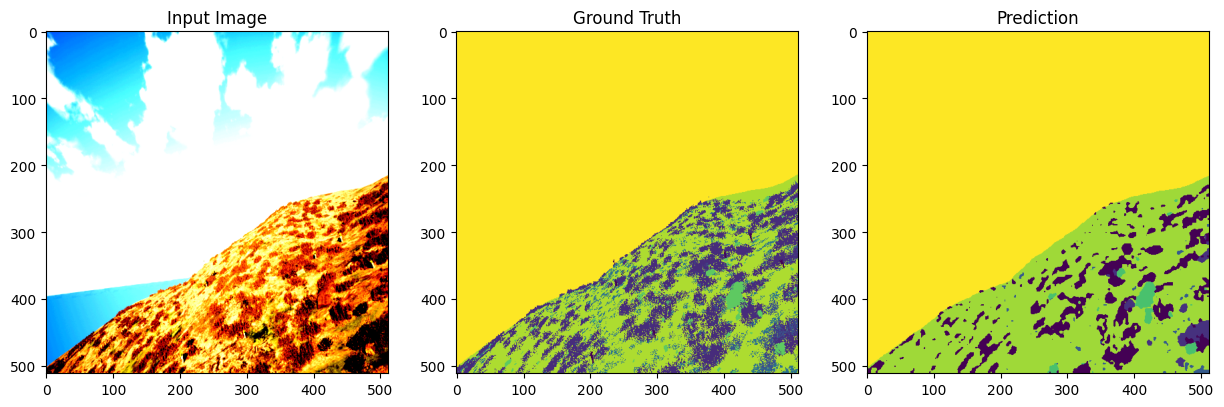

In [41]:
import matplotlib.pyplot as plt

model.eval()
batch = next(iter(val_loader))
pixel_values = batch["pixel_values"].to(device)
labels = batch["labels"]

with torch.no_grad():
    outputs = model(pixel_values=pixel_values)

logits = torch.nn.functional.interpolate(
    outputs.logits,
    size=labels.shape[-2:],
    mode="bilinear",
    align_corners=False
)
pred_mask = logits.argmax(dim=1)[0].cpu().numpy()
true_mask = labels[0].numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(pixel_values[0].cpu().permute(1, 2, 0))
axes[0].set_title("Input Image")
axes[1].imshow(true_mask)
axes[1].set_title("Ground Truth")
axes[2].imshow(pred_mask)
axes[2].set_title("Prediction")
plt.show()


## Typical Flow Summary


In [42]:
test_img_dir = "/kaggle/input/datasets/navyaminocha/offroad-test/Offroad_Segmentation_testImages/Color_Images"

test_mask_dir = "/kaggle/input/datasets/navyaminocha/offroad-test/Offroad_Segmentation_testImages/Segmentation"

In [43]:
test_dataset = SegDataset(
    test_img_dir,
    test_mask_dir,
    processor,
    transform=val_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

In [47]:
class TestDataset(Dataset):
    def __init__(self, image_dir, processor, transform=None):
        self.image_dir = image_dir
        self.processor = processor
        self.transform = transform
        self.images = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        image = np.array(Image.open(os.path.join(self.image_dir, img_name)).convert("RGB"))

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented["image"]

        inputs = self.processor(
            images=image,
            return_tensors="pt"
        )

        return {
            "pixel_values": inputs["pixel_values"].squeeze(),
            "image_name": img_name
        }

In [48]:
from sklearn.metrics import jaccard_score
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].long().to(device)

        outputs = model(pixel_values=pixel_values)
        logits = outputs.logits

        logits = F.interpolate(
            logits,
            size=labels.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate([p.flatten() for p in all_preds])
all_labels = np.concatenate([l.flatten() for l in all_labels])

miou = jaccard_score(all_labels, all_preds, average="macro")

print(f"Epoch {epoch+1} mIoU: {miou:.4f}")

Epoch 10 mIoU: 0.5978


ValueError: x and y must have same first dimension, but have shapes (10,) and (0,)

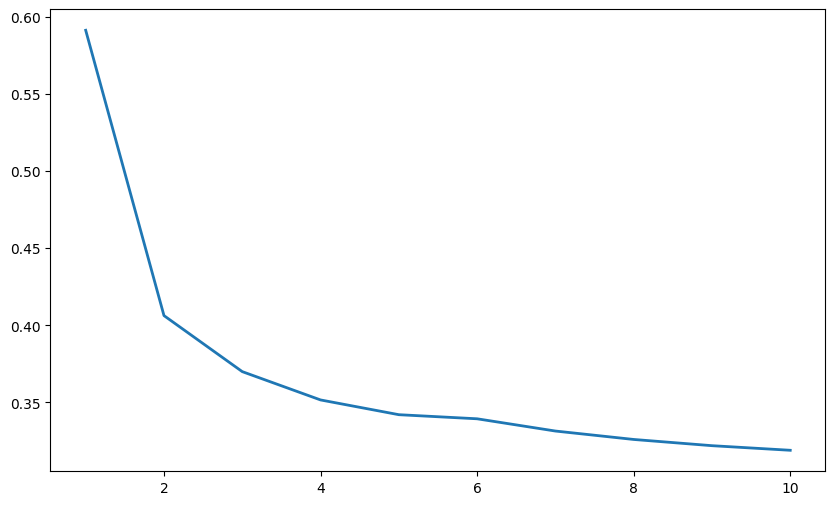

In [49]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))

plt.plot(epochs, train_losses, linewidth=2)
plt.plot(epochs, val_losses, linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.legend(["Train Loss", "Validation Loss"])
plt.grid(True)

plt.tight_layout()
plt.show()